In [1]:

import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

In [16]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [3]:
iris = load_iris()

In [4]:
X = pd.DataFrame(iris.data)
X.columns = iris.feature_names
y = iris.target

In [5]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
X.shape

(150, 4)

In [7]:
X = iris.data
y = iris.target

In [8]:
#visualize

<Axes: >

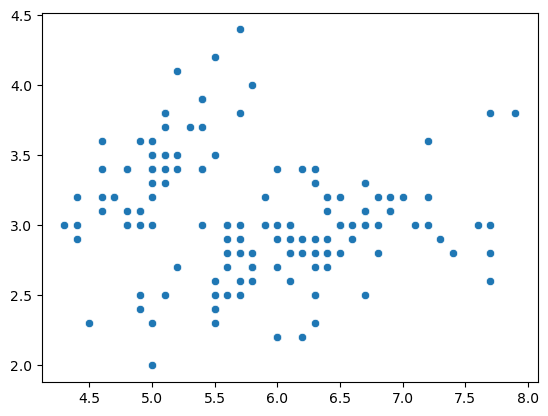

In [9]:
sns.scatterplot(x=X[:,0],y=X[:,1])

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data=pca.fit_transform(X_scaled)

In [29]:
wcss =[]

for k in range(1,11):
    kmeans= KMeans(n_clusters=k)
    #kmeans.fit(X_scaled)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

<Axes: >

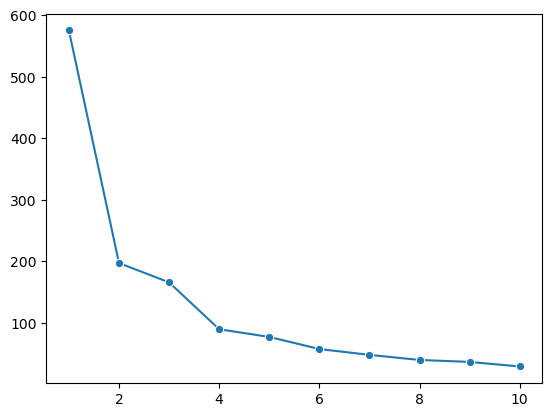

In [30]:
sns.lineplot(x=range(1,11),y=wcss,marker='o')

In [31]:
kmeans = KMeans(n_clusters=3)
# labels = kmeans.fit_predict(X_scaled)
labels = kmeans.fit_predict(pca_data)

<Axes: >

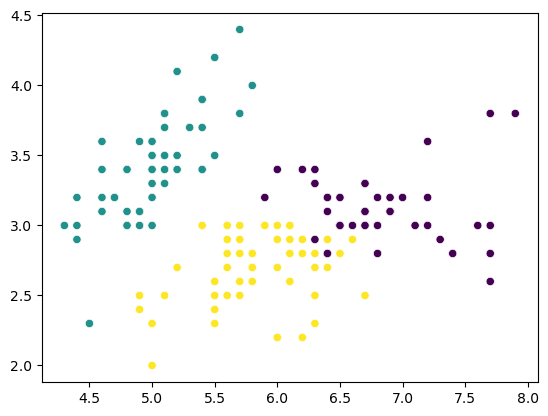

In [39]:
#predicted cluster

# sns.scatterplot(x = X[:, 0], y = X[:, 2], c = lables)
sns.scatterplot(x = X[:, 0], y = X[:, 1], c = lables)

<Axes: >

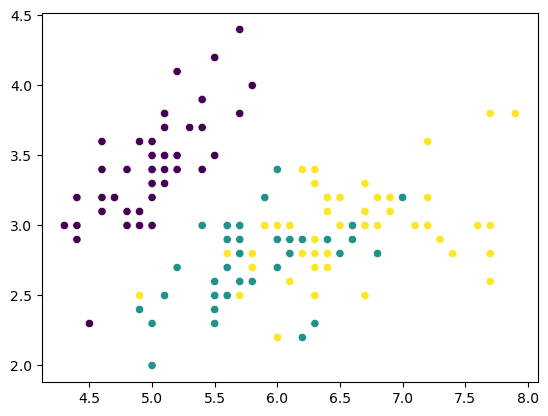

In [40]:
# Original CLusters
sns.scatterplot(x=X[:, 0], y= X[:,1], c=y)